In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score, 
    classification_report
)
from scipy.stats import randint
import pandas as pd
import numpy as np
import joblib


import os

import shap

c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
X_train_others = pd.read_parquet('X_train_others.parquet')
y_train_others = pd.read_parquet('y_train_others.parquet')
X_train_others_smote = pd.read_parquet('X_train_others_smote.parquet')
y_train_others_smote = pd.read_parquet('y_train_others_smote.parquet')
X_val_others = pd.read_parquet('X_val_others.parquet')
y_val_others = pd.read_parquet('y_val_others.parquet')
X_test_others = pd.read_parquet('X_test_others.parquet')
y_test_others = pd.read_parquet('y_test_others.parquet')

In [3]:
param_dist = {
    "n_estimators": randint(100, 400),

    "max_depth": [10, 20, 30],

    "min_samples_split": randint(2, 10),

    "min_samples_leaf": randint(1, 5),

    "max_features": ["sqrt", "log2"],

    "bootstrap": [True],

    "criterion": ["gini"],

    "class_weight": [None, "balanced"]
}

In [4]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

random_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=75,
    scoring="f1",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train_others, y_train_others)

best_rf = random_rf.best_estimator_

print("Best Random Forest Parameters:")
print(random_rf.best_params_)

print('\nBest Random Forest F1 Score:')
print(random_rf.best_score_)

Fitting 5 folds for each of 75 candidates, totalling 375 fits


c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best Random Forest Parameters:
{'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 7, 'n_estimators': 198}

Best Random Forest F1 Score:
0.28034818897443864


Save the model

In [5]:
os.makedirs("models", exist_ok=True)
joblib.dump(best_rf, 'models/best_rf.pkl')

['models/best_rf.pkl']

Find the best threshold

In [6]:
val_prob = best_rf.predict_proba(X_val_others)[:, 1]

thresholds = np.arange(0.05, 1.00, 0.05)

best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    pred = (val_prob >= t).astype(int)
    score = f1_score(y_val_others, pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best threshold:", best_threshold)
print("Validation F1:", best_f1)

Best threshold: 0.5
Validation F1: 0.2855419610546269


Test on the test dataset

In [7]:
test_prob = best_rf.predict_proba(X_test_others)[:, 1]

test_pred = (test_prob >= best_threshold).astype(int)

print(classification_report(y_test_others, test_pred))

              precision    recall  f1-score   support

           0       0.94      0.87      0.91     56538
           1       0.22      0.41      0.29      4965

    accuracy                           0.83     61503
   macro avg       0.58      0.64      0.60     61503
weighted avg       0.89      0.83      0.86     61503



Shapley values

In [5]:
best_rf = joblib.load('models/best_rf.pkl')

In [8]:
# Sample the test set for faster SHAP computation
X_sample = X_test_others.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer(X_sample)



In [10]:
os.makedirs("model_results", exist_ok=True)

In [11]:
joblib.dump(shap_values, "model_results/shap_values_rf.pkl")

['model_results/shap_values_rf.pkl']

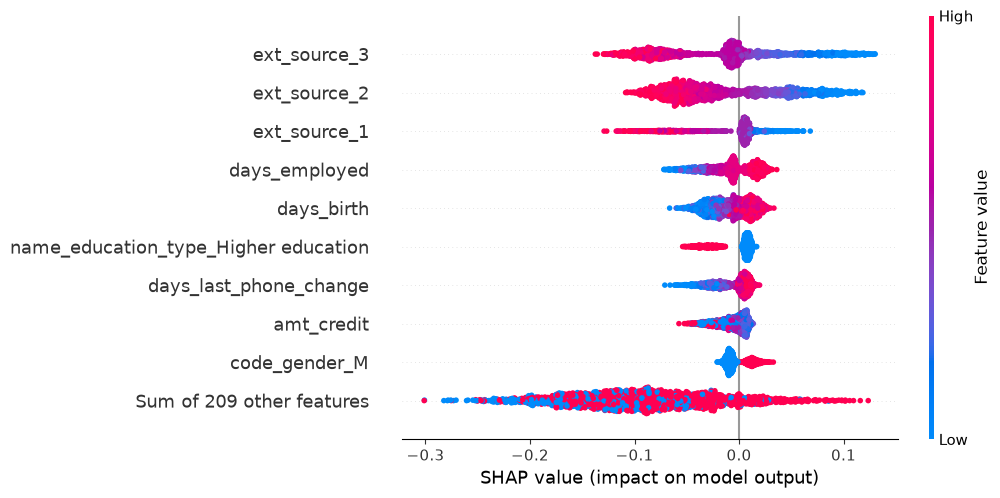

In [15]:
shap.plots.beeswarm(shap_values[:, :, 1]) #only class 1 is chosen

In [13]:
print(shap_values.shape)

(2000, 218, 2)


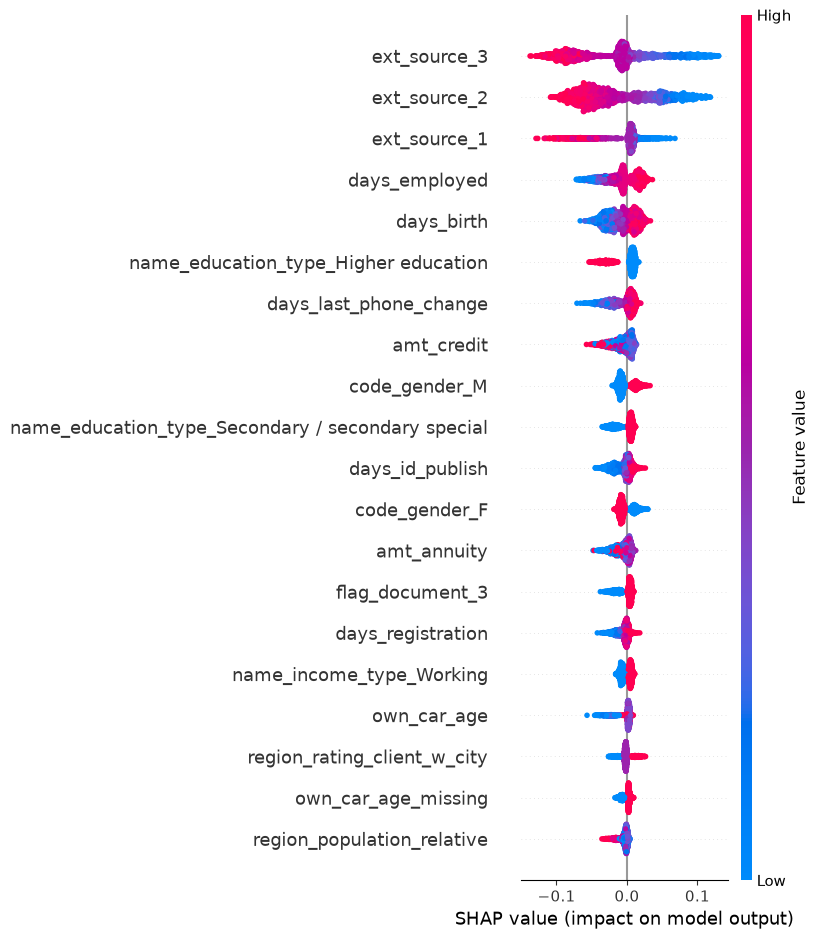

In [17]:
shap.summary_plot(shap_values[:, :, 1])

### Train on SMOTE data

In [18]:
param_dist_sm = {
    "n_estimators": randint(100, 400),

    "max_depth": [10, 20, 30],

    "min_samples_split": randint(2, 10),

    "min_samples_leaf": randint(1, 5),

    "max_features": ["sqrt", "log2"],

    "bootstrap": [True],

    "criterion": ["gini"]
}

In [19]:
rf_smote = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

random_rf_smote = RandomizedSearchCV(
    estimator=rf_smote,
    param_distributions=param_dist_sm,
    n_iter=75,
    scoring="f1",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_rf_smote.fit(X_train_others_smote, y_train_others_smote)

best_rf_smote = random_rf_smote.best_estimator_

print(random_rf_smote.best_params_)
print(random_rf_smote.best_score_)

Fitting 3 folds for each of 75 candidates, totalling 225 fits


c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


{'bootstrap': True, 'criterion': 'gini', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 198}
0.9491158368681784


Save the model

In [20]:
joblib.dump(best_rf_smote, 'best_rf_smote.pkl')

['best_rf_smote.pkl']

Find the best threshold

In [21]:
val_prob_smote = best_rf_smote.predict_proba(X_val_others)[:, 1]

thresholds = np.arange(0.05, 1.00, 0.05)

best_threshold_smote = 0.5
best_f1_smote = 0

for t in thresholds:
    pred = (val_prob_smote >= t).astype(int)
    score = f1_score(y_val_others, pred)

    if score > best_f1_smote:
        best_f1_smote = score
        best_threshold_smote = t

print("Best threshold:", best_threshold_smote)
print("Validation F1:", best_f1_smote)

Best threshold: 0.15000000000000002
Validation F1: 0.2650957290132548


Test on test dataset

In [22]:
test_prob_smote = best_rf_smote.predict_proba(X_test_others)[:, 1]

test_pred_smote = (test_prob_smote >= best_threshold_smote).astype(int)

print(classification_report(y_test_others, test_pred_smote))

              precision    recall  f1-score   support

           0       0.94      0.84      0.89     56538
           1       0.19      0.43      0.27      4965

    accuracy                           0.81     61503
   macro avg       0.57      0.64      0.58     61503
weighted avg       0.88      0.81      0.84     61503



Shapley values

In [ ]:
explainer_sm = shap.TreeExplainer(best_rf_smote)
shap_values_sm = explainer_sm(X_test_others)

shap.plots.beeswarm(shap_values_sm)